# Notebook 1 — Curve Construction

This notebook walks through the two curves that underpin every CDS price:

- **Discount Curve** — what is £1 received in the future worth today?
- **Survival Curve** — what is the probability the entity is still alive at time t?

We build both from scratch using dummy market data calibrated to realistic Jun 2026 levels,
then visualise the results to develop intuition for how credit quality translates into curve shape.

In [1]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import date

from cds.curves import DiscountCurve, SurvivalCurve

# ── Plot style ────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.grid':         True,
    'grid.color':        '#e5e5e5',
    'grid.linewidth':    0.8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'sans-serif',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
})

COLOURS = {
    'ig':         '#2563EB',   # blue   — investment grade
    'hy':         '#F97316',   # orange — high yield
    'distressed': '#DC2626',   # red    — distressed
    'discount':   '#16A34A',   # green  — discount curve
}

print('Libraries loaded.')

Libraries loaded.


In [2]:
# ── Load dummy market data ────────────────────────────────────
with open('../data/dummy/market_data.json') as f:
    mkt = json.load(f)

# Parse swap rates — keys are strings in JSON, convert to float
swap_rates = {float(k): v for k, v in mkt['swap_curve'].items()
              if k != 'comment'}

# Parse spread curves
def parse_spreads(entity: str) -> dict:
    return {
        float(k): v
        for k, v in mkt['spread_curves'][entity].items()
        if k not in ('name', 'rating', 'sector', 'recovery', 'comment')
    }

spreads_ig   = parse_spreads('VOD')
spreads_hy   = parse_spreads('XOVER')
spreads_dist = parse_spreads('DISTRESSED')

TRADE_DATE = date(2026, 6, 13)

print('Market data loaded.')
print(f'  Swap rates:   {swap_rates}')
print(f'  IG spreads:   {spreads_ig}')
print(f'  HY spreads:   {spreads_hy}')

Market data loaded.
  Swap rates:   {1.0: 0.0432, 2.0: 0.0418, 3.0: 0.0401, 5.0: 0.0385, 7.0: 0.0379, 10.0: 0.0371}
  IG spreads:   {1.0: 45, 2.0: 65, 3.0: 90, 5.0: 120, 7.0: 145, 10.0: 170}
  HY spreads:   {1.0: 180, 2.0: 230, 3.0: 265, 5.0: 310, 7.0: 340, 10.0: 375}


---
## 1. Discount Curve

Built from continuously compounded swap rates.

$$DF(t) = e^{-r(t) \cdot t}$$

Between tenor nodes we interpolate linearly on the rate before applying the formula.

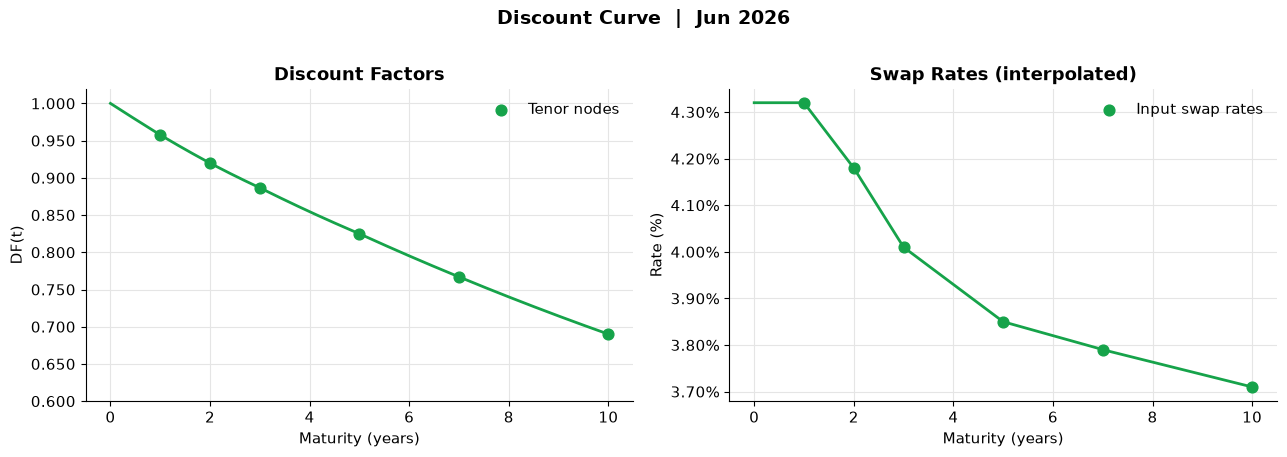

Discount factors at tenor nodes:
     1Y:  DF = 0.9577  |  Rate = 4.320%
     2Y:  DF = 0.9198  |  Rate = 4.180%
     3Y:  DF = 0.8867  |  Rate = 4.010%
     5Y:  DF = 0.8249  |  Rate = 3.850%
     7Y:  DF = 0.7670  |  Rate = 3.790%
    10Y:  DF = 0.6900  |  Rate = 3.710%


In [3]:
dc = DiscountCurve(swap_rates)

# Evaluate on a fine grid
t_grid = np.linspace(0, 10, 500)
dfs    = [dc.discount_factor(t) for t in t_grid]
rates  = [dc.rate(t) * 100 for t in t_grid]  # → percent

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Discount Curve  |  Jun 2026', fontsize=14, fontweight='bold', y=1.01)

# Left: Discount factors
ax = axes[0]
ax.plot(t_grid, dfs, color=COLOURS['discount'], lw=2)
ax.scatter(list(swap_rates.keys()),
           [dc.discount_factor(t) for t in swap_rates],
           color=COLOURS['discount'], zorder=5, s=60, label='Tenor nodes')
ax.set_title('Discount Factors')
ax.set_xlabel('Maturity (years)')
ax.set_ylabel('DF(t)')
ax.set_ylim(0.6, 1.02)
ax.legend(frameon=False)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

# Right: Interpolated rates
ax = axes[1]
ax.plot(t_grid, rates, color=COLOURS['discount'], lw=2)
ax.scatter(list(swap_rates.keys()),
           [v * 100 for v in swap_rates.values()],
           color=COLOURS['discount'], zorder=5, s=60, label='Input swap rates')
ax.set_title('Swap Rates (interpolated)')
ax.set_xlabel('Maturity (years)')
ax.set_ylabel('Rate (%)')
ax.legend(frameon=False)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))

plt.tight_layout()
plt.savefig('../outputs/01a_discount_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Print key values
print('Discount factors at tenor nodes:')
for t in sorted(swap_rates):
    print(f'  {t:>4.0f}Y:  DF = {dc.discount_factor(t):.4f}  |  Rate = {dc.rate(t)*100:.3f}%')

---
## 2. Survival Curves — IG vs HY vs Distressed

Bootstrapped from CDS par spreads using piecewise constant hazard rates.

$$S(t) = e^{-\int_0^t \lambda(s)\, ds}$$

Each tenor node is solved independently: find $\lambda_n$ such that the CDS NPV = 0,
holding all previously solved segments fixed.

Bootstrapping survival curves...
Done.


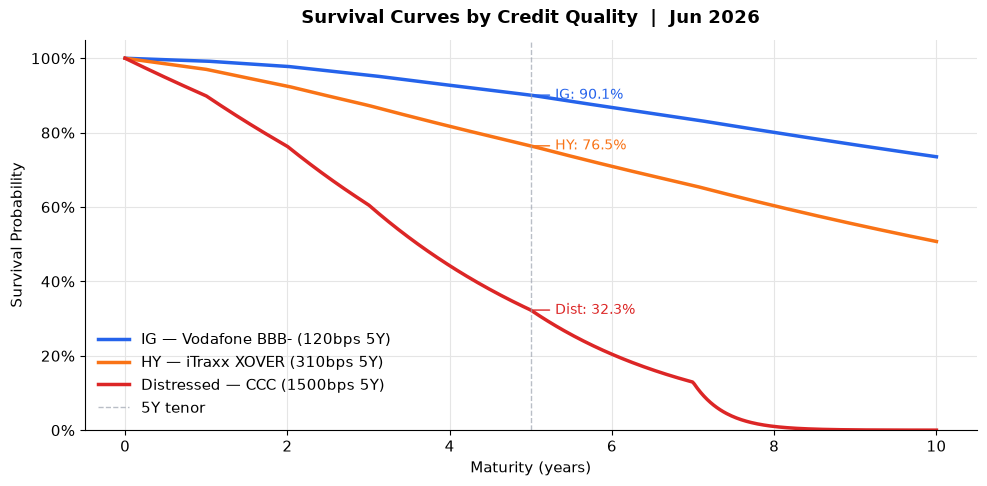


Survival probabilities at key tenors:
 Tenor        IG        HY  Distressed
--------------------------------------
    1Y    99.24%    97.02%      89.88%
    2Y    97.82%    92.51%      76.31%
    3Y    95.48%    87.31%      60.59%
    5Y    90.09%    76.46%      32.29%
    7Y    83.56%    65.81%      12.91%
   10Y    73.51%    50.73%       0.01%


In [4]:
print('Bootstrapping survival curves...')
sc_ig   = SurvivalCurve(spreads_ig,   dc, recovery=0.40, trade_date=TRADE_DATE)
sc_hy   = SurvivalCurve(spreads_hy,   dc, recovery=0.40, trade_date=TRADE_DATE)
sc_dist = SurvivalCurve(spreads_dist, dc, recovery=0.25, trade_date=TRADE_DATE)
print('Done.')

# Survival probabilities on fine grid
sp_ig   = [sc_ig.survival_prob(t)   for t in t_grid]
sp_hy   = [sc_hy.survival_prob(t)   for t in t_grid]
sp_dist = [sc_dist.survival_prob(t) for t in t_grid]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(t_grid, sp_ig,   color=COLOURS['ig'],         lw=2.5, label='IG — Vodafone BBB- (120bps 5Y)')
ax.plot(t_grid, sp_hy,   color=COLOURS['hy'],         lw=2.5, label='HY — iTraxx XOVER (310bps 5Y)')
ax.plot(t_grid, sp_dist, color=COLOURS['distressed'],  lw=2.5, label='Distressed — CCC (1500bps 5Y)')

# Annotate 5Y survival probabilities
for sc, col, label in [
    (sc_ig,   COLOURS['ig'],         'IG'),
    (sc_hy,   COLOURS['hy'],         'HY'),
    (sc_dist, COLOURS['distressed'], 'Dist'),
]:
    sp5 = sc.survival_prob(5)
    ax.annotate(
        f'{label}: {sp5:.1%}',
        xy=(5, sp5), xytext=(5.3, sp5),
        color=col, fontsize=10, va='center',
        arrowprops=dict(arrowstyle='-', color=col, lw=1)
    )

ax.axvline(5, color='#9CA3AF', lw=1, linestyle='--', alpha=0.7, label='5Y tenor')
ax.set_title('Survival Curves by Credit Quality  |  Jun 2026', pad=12)
ax.set_xlabel('Maturity (years)')
ax.set_ylabel('Survival Probability')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_ylim(0, 1.05)
ax.legend(frameon=False, loc='lower left')

plt.tight_layout()
plt.savefig('../outputs/01b_survival_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSurvival probabilities at key tenors:')
print(f'{"Tenor":>6}  {"IG":>8}  {"HY":>8}  {"Distressed":>10}')
print('-' * 38)
for t in [1, 2, 3, 5, 7, 10]:
    print(f'{t:>5}Y  {sc_ig.survival_prob(t):>8.2%}  '
          f'{sc_hy.survival_prob(t):>8.2%}  '
          f'{sc_dist.survival_prob(t):>10.2%}')

---
## 3. Hazard Rate Term Structure

The bootstrapped piecewise constant hazard rate $\lambda_n$ for each tenor segment.
This is the instantaneous conditional default probability — given survival to time t,
the probability of defaulting in the next instant.

A steep hazard rate curve implies the market prices near-term default risk much higher
than long-term — typical of distressed credits.

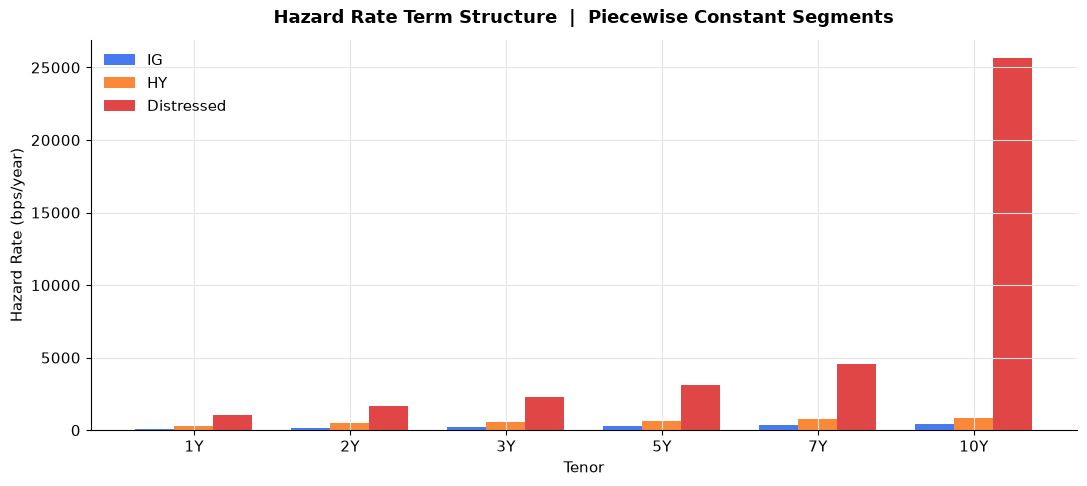

Hazard rates by tenor (bps/year):
 Tenor        IG        HY  Distressed
--------------------------------------
    1Y      76.0     303.0      1067.4
    2Y     144.5     475.7      1636.2
    3Y     242.3     578.1      2306.2
    5Y     290.6     663.7      3146.7
    7Y     376.3     749.9      4584.0
   10Y     426.8     867.3     25636.1


In [5]:
tenors = sorted(spreads_ig.keys())
labels = [f'{int(t)}Y' for t in tenors]
x      = np.arange(len(tenors))
width  = 0.25

hz_ig   = [sc_ig.hazard_rate(t)   * 10_000 for t in tenors]  # → bps
hz_hy   = [sc_hy.hazard_rate(t)   * 10_000 for t in tenors]
hz_dist = [sc_dist.hazard_rate(t) * 10_000 for t in tenors]

fig, ax = plt.subplots(figsize=(11, 5))

ax.bar(x - width, hz_ig,   width, label='IG',         color=COLOURS['ig'],         alpha=0.85)
ax.bar(x,         hz_hy,   width, label='HY',         color=COLOURS['hy'],         alpha=0.85)
ax.bar(x + width, hz_dist, width, label='Distressed', color=COLOURS['distressed'], alpha=0.85)

ax.set_title('Hazard Rate Term Structure  |  Piecewise Constant Segments', pad=12)
ax.set_xlabel('Tenor')
ax.set_ylabel('Hazard Rate (bps/year)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('../outputs/01c_hazard_rates.png', dpi=150, bbox_inches='tight')
plt.show()

print('Hazard rates by tenor (bps/year):')
print(f'{"Tenor":>6}  {"IG":>8}  {"HY":>8}  {"Distressed":>10}')
print('-' * 38)
for t, label in zip(tenors, labels):
    print(f'{label:>6}  {sc_ig.hazard_rate(t)*10000:>8.1f}  '
          f'{sc_hy.hazard_rate(t)*10000:>8.1f}  '
          f'{sc_dist.hazard_rate(t)*10000:>10.1f}')

---
## 4. Reprice Validation

The critical self-consistency check. If the bootstrapper is correct,
repricing each input spread using the bootstrapped curve must return NPV ≈ 0.

Any deviation > 1e-4 indicates a bug in the bootstrapper.

In [6]:
print('Reprice validation — IG curve:')
print(f'{"Tenor":>6}  {"Input Spread":>14}  {"NPV":>12}  {"Pass":>6}')
print('-' * 44)

tenors_sorted  = sorted(spreads_ig.keys())
hazards        = sc_ig._hazards

all_pass = True
for i, tenor in enumerate(tenors_sorted):
    spread = spreads_ig[tenor]
    npv    = sc_ig._price_cds(
        tenor,
        spread / 10_000,
        tenors_sorted[:i+1],
        hazards[:i+1]
    )
    passed = abs(npv) < 1e-4
    if not passed:
        all_pass = False
    print(f'{int(tenor):>5}Y  {spread:>12.0f}bps  {npv:>12.2e}  {"✓" if passed else "✗ FAIL":>6}')

print()
print(f'Result: {"ALL PASS ✓" if all_pass else "FAILURES DETECTED ✗"}')

Reprice validation — IG curve:
 Tenor    Input Spread           NPV    Pass
--------------------------------------------
    1Y            45bps     -8.17e-14       ✓
    2Y            65bps     -3.72e-12       ✓
    3Y            90bps      5.79e-16       ✓
    5Y           120bps      1.23e-11       ✓
    7Y           145bps      6.94e-17       ✓
   10Y           170bps      6.71e-13       ✓

Result: ALL PASS ✓


---
## 5. Implied Default Probability by Period

The marginal default probability in each quarterly period:

$$PD(t_i) = S(t_{i-1}) - S(t_i)$$

This shows where the market prices default risk most acutely across the life of the contract.

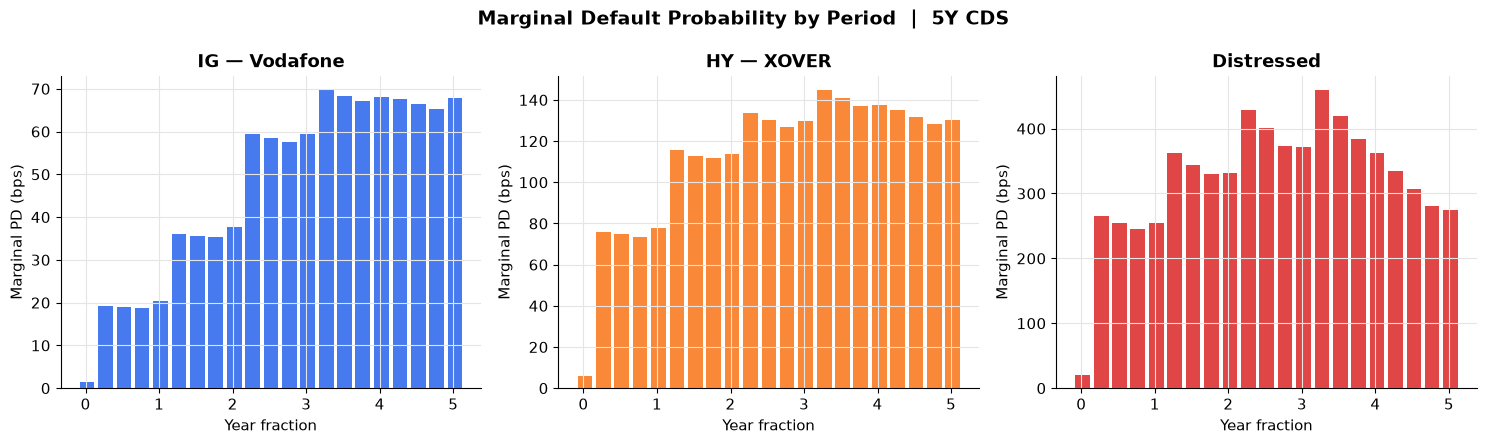

In [7]:
from cds.schedule import build_schedule
from datetime import date

maturity = date(2031, 6, 20)
schedule = build_schedule(TRADE_DATE, maturity)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Marginal Default Probability by Period  |  5Y CDS', 
             fontsize=14, fontweight='bold')

for ax, (sc, col, name) in zip(axes, [
    (sc_ig,   COLOURS['ig'],         'IG — Vodafone'),
    (sc_hy,   COLOURS['hy'],         'HY — XOVER'),
    (sc_dist, COLOURS['distressed'], 'Distressed'),
]):
    s_prev = 1.0
    yfs, pds = [], []

    for (t_start, t_end, dcf, yf) in schedule:
        s_end = sc.survival_prob(yf)
        pd    = (s_prev - s_end) * 10_000  # → bps
        yfs.append(yf)
        pds.append(pd)
        s_prev = s_end

    ax.bar(yfs, pds, width=0.20, color=col, alpha=0.85)
    ax.set_title(name)
    ax.set_xlabel('Year fraction')
    ax.set_ylabel('Marginal PD (bps)')

plt.tight_layout()
plt.savefig('../outputs/01d_marginal_pd.png', dpi=150, bbox_inches='tight')
plt.show()